# **Cellular automaton in Rust-Python**

Demo integration of parallelized Rust into Python. Parallelization is achieved using [`Rayon`](https://docs.rs/rayon/latest/rayon/).

The core Rust module is a simple cellular automaton model – Conway's Game of Life – [adapted from code](https://github.com/rayon-rs/rayon/tree/main/rayon-demo/src/life) provided by the `Rayon` developers.

This notebook can be run from the command line, without the need to fire up Jupyter and run interactively, if you type `ipython notebooks/life.ipynb` in a terminal. To make this work, first `uv pip install nbformat`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from numpy.typing import NDArray

In [2]:
from dprs import sim
sim

<module 'dprs.sim' from '/Users/cps/Projects/DPRS/.venv/lib/python3.14/site-packages/dprs/sim.cpython-314-darwin.so'>

In [3]:
n_x: int = 10_000
n_y: int = 10_000
n_iterations: int = 100
slow_factor: int = 10
n_threads: int = 16

Execute the Rust-coded sim:

In [4]:
raw_lattice: list = sim.life(
    n_x, n_y, n_iterations, slow_factor, n_threads,
)

life: 10000 10000 100 10 16

Grid width:  x=10000
Grid height: y=10000
Iterations:  n=100
Slow factor: s=10
Threads: n_threads=16

Serial:   41.484s
Parallel: 3.712s
Speedup => 11.18x



The final model lattice is returned as a 1d list: next we convert it into the correctly shaped numpy array (2d grid):

In [5]:
lattice: NDArray = np.array(raw_lattice, dtype=np.bool,).reshape(n_x, n_y,)

Plot the low-left portion of the lattice:

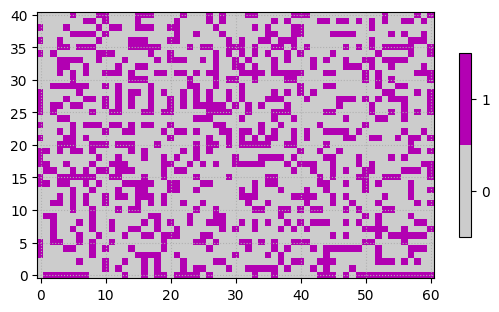

In [6]:
color_map = ListedColormap(((0.8, 0.8, 0.8,), (0.7, 0, 0.7),))
plt.imshow(((lattice[0:61,0:41].T)), cmap=color_map, origin="lower",)
color_bar = plt.colorbar(
    ticks=(0.25, 0.75,), shrink=0.5*(n_y/n_x)**0.25, aspect=15,
)
color_bar.set_ticklabels((0, 1))
plt.grid(ls=":")
plt.show()